In [1]:
import numpy as np 
import pandas as pd 
import utils
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker


In [2]:
gama, nessie_groups, sussex_groups, bij = utils.load_group_set_gama()

In [3]:
nessie_groups = nessie_groups[nessie_groups['IterCenZ'] < 0.3]


In [24]:
# GAMA II region bounds (J2000), from Liske et al. 2015 Table 1
GAMA_REGIONS = {
    "G09": {"RA_min": 129.0, "RA_max": 141.0, "Dec_min": -2.0,  "Dec_max":  3.0},
    "G12": {"RA_min": 174.0, "RA_max": 186.0, "Dec_min": -3.0,  "Dec_max":  2.0},
    "G15": {"RA_min": 211.5, "RA_max": 223.5, "Dec_min": -2.0,  "Dec_max":  3.0},
    "G23": {"RA_min": 339.0, "RA_max": 351.0, "Dec_min": -35.0, "Dec_max": -30.0},
}


def wrap_ra_diff(ra, ra0):
    """Smallest signed RA difference in degrees, handling wrap-around."""
    return (ra - ra0 + 180.0) % 360.0 - 180.0


def assign_gama_regions(ra_deg, dec_deg, region_defs=None):
    if region_defs is None:
        region_defs = GAMA_REGIONS
    ra = np.asarray(ra_deg) % 360.0
    dec = np.asarray(dec_deg)
    region_names = np.full(len(ra), None, dtype=object)
    for name, lim in region_defs.items():
        in_ra  = (ra  >= lim["RA_min"])  & (ra  <= lim["RA_max"])
        in_dec = (dec >= lim["Dec_min"]) & (dec <= lim["Dec_max"])
        region_names[in_ra & in_dec] = name
    return region_names


def build_region_metadata(region_defs=None):
    if region_defs is None:
        region_defs = GAMA_REGIONS
    rows = []
    for name, lim in region_defs.items():
        ra0  = 0.5 * (lim["RA_min"] + lim["RA_max"])
        dec0 = 0.5 * (lim["Dec_min"] + lim["Dec_max"])
        rows.append({
            "region":  name,
            "RA0":     ra0,  "Dec0":    dec0,
            "RA_min":  lim["RA_min"],  "RA_max":  lim["RA_max"],
            "Dec_min": lim["Dec_min"], "Dec_max": lim["Dec_max"],
            "dRA_min": lim["RA_min"] - ra0,
            "dRA_max": lim["RA_max"] - ra0,
        })
    return pd.DataFrame(rows)


def prepare_wedge_catalog(df, ra_col="RAcen", dec_col="Deccen", z_col="Z",
                          cosmo=None, region_defs=None):
    if cosmo is None:
        cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    if region_defs is None:
        region_defs = GAMA_REGIONS

    plot_df = df[[ra_col, dec_col, z_col]].copy()
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
    plot_df = plot_df[plot_df[z_col] > 0].copy()
    plot_df["region"] = assign_gama_regions(
        plot_df[ra_col].values, plot_df[dec_col].values, region_defs=region_defs)
    plot_df = plot_df[plot_df["region"].notna()].copy()

    region_meta = build_region_metadata(region_defs=region_defs)
    plot_df["Dc_Mpc"] = cosmo.comoving_distance(plot_df[z_col].values).value
    plot_df = plot_df.join(region_meta.set_index("region"), on="region")

    # Angular coordinate (radians from region centre)
    delta_ra_deg      = wrap_ra_diff(plot_df[ra_col].values, plot_df["RA0"].values)
    dec0_rad          = np.deg2rad(plot_df["Dec0"].values)
    plot_df["theta_rad"] = np.deg2rad(delta_ra_deg) * np.cos(dec0_rad)

    return plot_df, region_meta


# ---------------------------------------------------------------------------
# Internal helpers for drawing the wedge frame on a plain Cartesian axes.
#
# Convention: the wedge opens upward.
#   x  =  r * sin(theta)   — angular direction (RA), zero at centre
#   y  =  r * cos(theta)   — radial direction (distance / redshift)
# theta_min < 0 (left edge), theta_max > 0 (right edge)
# ---------------------------------------------------------------------------

def _wedge_xy_limits(theta_min, theta_max, r_max, pad=0.05):
    """Tight (x0, x1, y0, y1) bounding box. Wedge opens rightward:
    x = r·cos θ (radial), y = r·sin θ (angular)."""
    x0, x1 = 0.0, r_max
    y0 = r_max * np.sin(theta_min)   # negative
    y1 = r_max * np.sin(theta_max)   # positive
    dx, dy = x1 - x0, y1 - y0
    return x0 - pad * dx, x1 + pad * dx, y0 - pad * dy, y1 + pad * dy


def _draw_wedge_frame(ax, theta_min, theta_max, r_max, n=300,
                      color="0.25", lw=0.9):
    for theta in (theta_min, theta_max):
        ax.plot([0, r_max * np.cos(theta)], [0, r_max * np.sin(theta)],
                color=color, lw=lw, zorder=1)
    t = np.linspace(theta_min, theta_max, n)
    ax.plot(r_max * np.cos(t), r_max * np.sin(t), color=color, lw=lw, zorder=1)


def _draw_arc_gridlines(ax, theta_min, theta_max, r_ticks, n=200,
                         color="0.82", lw=0.4, ls="--"):
    t = np.linspace(theta_min, theta_max, n)
    for r in r_ticks:
        ax.plot(r * np.cos(t), r * np.sin(t), color=color, lw=lw,
                linestyle=ls, zorder=0)


def _draw_radial_gridlines(ax, theta_ticks, r_max,
                            color="0.82", lw=0.4, ls="--"):
    for theta in theta_ticks:
        ax.plot([0, r_max * np.cos(theta)], [0, r_max * np.sin(theta)],
                color=color, lw=lw, linestyle=ls, zorder=0)


def _add_ra_labels(ax, ra_vals, theta_ticks, r_max, fontsize=8, pad=1.05):
    """RA labels along the outer arc."""
    for ra, theta in zip(ra_vals, theta_ticks):
        x = pad * r_max * np.cos(theta)
        y = pad * r_max * np.sin(theta)
        va = "center"
        if   np.sin(theta) >  0.1: va = "bottom"
        elif np.sin(theta) < -0.1: va = "top"
        ax.text(x, y, f"{ra:.0f}°", ha="left", va=va,
                fontsize=fontsize, color="0.35")


def _add_distance_labels(ax, r_ticks, theta_bottom, use_redshift_y,
                          fontsize=7, pad=1.03):
    """Distance/redshift labels along the lower radial boundary."""
    for r in r_ticks:
        x = pad * r * np.cos(theta_bottom)
        y = pad * r * np.sin(theta_bottom)
        label = f"z={r:.2f}" if use_redshift_y else f"{r:.0f}"
        ax.text(x, y, label, ha="center", va="top",
                fontsize=fontsize, color="0.45")


def _dress_wedge_ax(ax, theta_min, theta_max, r_max,
                    ra_min, ra_max, ra0, dec0,
                    use_redshift_y=False, n_r_ticks=5, n_ra_ticks=5):
    """Draw all frame, grid, and label elements on a plain Cartesian axes."""
    _draw_wedge_frame(ax, theta_min, theta_max, r_max)

    r_ticks = np.linspace(0, r_max, n_r_ticks + 1)[1:]
    _draw_arc_gridlines(ax, theta_min, theta_max, r_ticks)
    _add_distance_labels(ax, r_ticks, theta_min, use_redshift_y)

    dec0_rad    = np.deg2rad(dec0)
    ra_vals     = np.linspace(ra_min, ra_max, n_ra_ticks)
    theta_ticks = np.deg2rad(wrap_ra_diff(ra_vals, ra0)) * np.cos(dec0_rad)
    _draw_radial_gridlines(ax, theta_ticks, r_max)
    _add_ra_labels(ax, ra_vals, theta_ticks, r_max)

    x0, x1, y0, y1 = _wedge_xy_limits(theta_min, theta_max, r_max)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal")
    ax.set_axis_off()


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def overlay_wedge_catalogs(
    catalogs,
    column_specs,
    labels,
    colors,
    markers,
    use_redshift_y=False,
    figsize=(8, 8),
    alpha=0.45,
    size=2.5,
    region_order=("G09", "G12", "G15", "G23"),
    region_defs=None,
):
    """
    Overlay multiple catalogues on Cartesian wedge panels for each GAMA region.

    Each panel is a plain Cartesian axes with manually drawn arcs, radial lines,
    and text labels — this eliminates the whitespace that polar axes impose
    (polar axes always allocate a full square regardless of wedge span).

    Parameters
    ----------
    catalogs      : list of DataFrames
    column_specs  : list of dicts  [{"ra": "...", "dec": "...", "z": "..."}, ...]
    labels        : list of str
    colors        : list of colour specs
    markers       : list of marker strings
    use_redshift_y: bool — label radial axis as redshift (True) or Dc/Mpc (False)
    figsize       : (width, height) in inches — height is overridden to fit content
    alpha, size   : scatter aesthetics
    region_order  : order of the 4 panels top-to-bottom
    region_defs   : override default GAMA_REGIONS dict
    """
    if region_defs is None:
        region_defs = GAMA_REGIONS

    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

    # --- prepare catalogues --------------------------------------------------
    prepared_catalogs = []
    region_meta = None
    for df, spec in zip(catalogs, column_specs):
        prep, region_meta = prepare_wedge_catalog(
            df, ra_col=spec["ra"], dec_col=spec["dec"], z_col=spec["z"],
            cosmo=cosmo, region_defs=region_defs)
        prepared_catalogs.append((prep, spec))

    region_meta = (region_meta.set_index("region")
                               .loc[list(region_order)]
                               .reset_index())

    # Global radial max
    all_rmax = 0.0
    for prep, spec in prepared_catalogs:
        if len(prep) == 0:
            continue
        col = spec["z"] if use_redshift_y else "Dc_Mpc"
        all_rmax = max(all_rmax, prep[col].max())
    all_rmax *= 1.05

    # --- compute per-panel geometry ------------------------------------------
    # Wedge opens rightward: data_w >> data_h (wide and thin).
    # We fix the axes HEIGHT per panel and derive its width from equal-aspect.
    #
    # Layout constants (in inches):
    top_frac    = 0.01   # figure fraction reserved above each panel for title
    bottom_frac = 0.01   # figure fraction below each panel for distance labels
    left_frac   = 0.01   # left margin
    right_frac  = 0.01   # right margin for RA labels

    n_panels   = len(region_order)
    gap_frac   = 0.02    # vertical gap between panels (figure fraction)
    usable_h   = 1.0 - (top_frac + bottom_frac) * n_panels - gap_frac * (n_panels - 1)
    ax_h_frac  = usable_h / n_panels   # figure-fraction height of each axes rect

    wedge_info = []
    for region in region_order:
        row = region_meta[region_meta["region"] == region].iloc[0]
        dec0_rad  = np.deg2rad(row["Dec0"])
        theta_min = np.deg2rad(row["dRA_min"]) * np.cos(dec0_rad)
        theta_max = np.deg2rad(row["dRA_max"]) * np.cos(dec0_rad)
        x0, x1, y0, y1 = _wedge_xy_limits(theta_min, theta_max, all_rmax)
        data_w = x1 - x0
        data_h = y1 - y0
        wedge_info.append(
            dict(row=row, theta_min=theta_min, theta_max=theta_max,
                 data_w=data_w, data_h=data_h))

    # Axes width fraction: equal-aspect means ax_w/ax_h = data_w/data_h.
    # All wedges share the same data_w (r_max + padding) but differ in data_h.
    # Use the narrowest wedge to set a common width so all fit horizontally.
    ax_h_inch   = figsize[1] * ax_h_frac
    max_data_ratio = max(w["data_w"] / w["data_h"] for w in wedge_info)
    ax_w_inch   = ax_h_inch * max_data_ratio
    ax_w_frac   = ax_w_inch / figsize[0]

    # If computed width exceeds available horizontal space, clamp and warn
    avail_w_frac = 1.0 - left_frac - right_frac
    if ax_w_frac > avail_w_frac:
        ax_w_frac = avail_w_frac
        ax_w_inch = figsize[0] * ax_w_frac

    fig = plt.figure(figsize=figsize)

    # --- place panels top-to-bottom ------------------------------------------
    cursor_frac = 1.0   # top of figure
    axes = []
    all_legend_handles = []
    all_legend_labels  = []

    for i, (region, wi) in enumerate(zip(region_order, wedge_info)):
        row       = wi["row"]
        theta_min = wi["theta_min"]
        theta_max = wi["theta_max"]

        # All panels share the same ax_w_frac so they are identical in width
        cursor_frac -= top_frac
        ax_b = cursor_frac - ax_h_frac
        ax   = fig.add_axes([left_frac, ax_b, ax_w_frac, ax_h_frac])

        _dress_wedge_ax(
            ax, theta_min, theta_max, all_rmax,
            ra_min=row["RA_min"], ra_max=row["RA_max"],
            ra0=row["RA0"],       dec0=row["Dec0"],
            use_redshift_y=use_redshift_y,
        )

        # --- scatter each catalogue ------------------------------------------
        for (plot_df, spec), label, color, marker in zip(
                prepared_catalogs, labels, colors, markers):
            sub = plot_df[plot_df["region"] == region]
            if len(sub) == 0:
                continue
            r     = sub[spec["z"]].values if use_redshift_y else sub["Dc_Mpc"].values
            theta = sub["theta_rad"].values
            sc = ax.scatter(
                r * np.cos(theta), r * np.sin(theta),
                s=size, alpha=alpha, c=color, marker=marker,
                rasterized=True, linewidths=0, zorder=3, label=label,
            )
            # Collect handles from first panel only (same for all panels)
            if i == 0:
                all_legend_handles.append(sc)
                all_legend_labels.append(label)

        # --- title above the panel -------------------------------------------
        ax.set_title(
            f"{region}   "
            rf"$\alpha={row['RA_min']:.1f}^\circ$–${row['RA_max']:.1f}^\circ$"
            rf",  $\delta={row['Dec_min']:.1f}^\circ$–${row['Dec_max']:.1f}^\circ$",
            fontsize=9, pad=4,
        )

        # --- radial axis label (along bottom of panel) -----------------------
        radial_label = ("Redshift $z$" if use_redshift_y
                        else r"$D_{\rm C}(z)\ [\rm{Mpc}]$")
        if i ==3:
            fig.text(
            left_frac + ax_w_frac * 0.5,
            ax_b - bottom_frac * 0.5,
            radial_label,
            ha="center", va="center", fontsize=8,
        )

        axes.append(ax)
        cursor_frac -= ax_h_frac + bottom_frac + gap_frac

    # --- legend at bottom centre of figure -----------------------------------
    if all_legend_handles:
        fig.legend(
            handles=all_legend_handles,
            labels=all_legend_labels,
            loc="lower center",
            bbox_to_anchor=(left_frac + ax_w_frac * 0.5, 0.005),
            bbox_transform=fig.transFigure,
            ncol=len(all_legend_labels),
            frameon=False,
            markerscale=2,
            fontsize=8,
        )

    return fig, axes, [p for p, _ in prepared_catalogs]

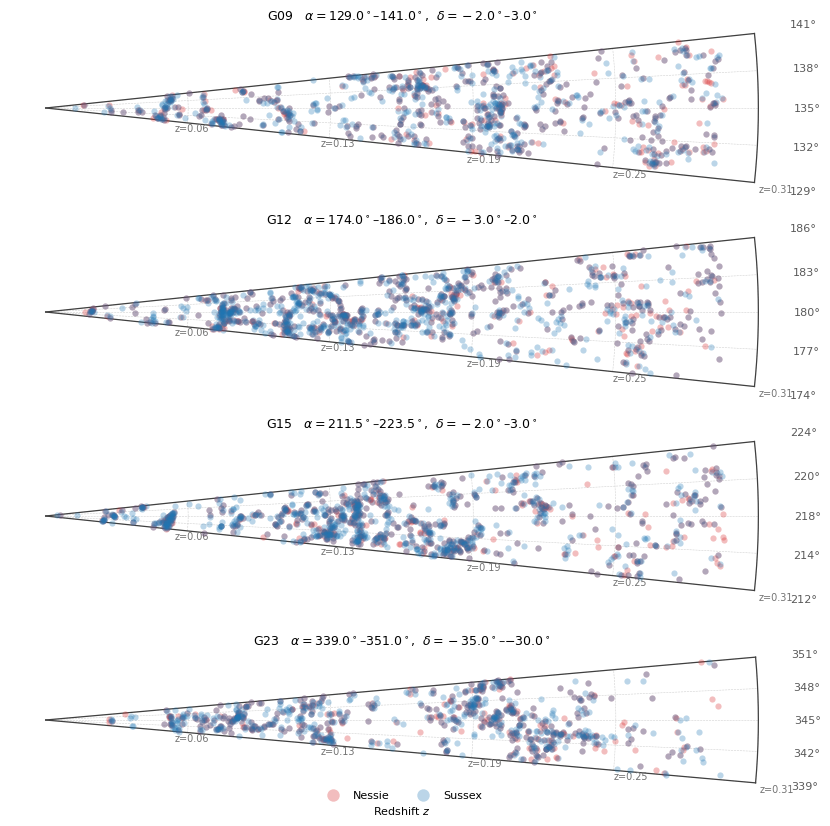

In [28]:
nessie_min_5 = nessie_groups[nessie_groups["Nfof"] >= 5]
sussex_min_5 = sussex_groups[sussex_groups["multiplicity"] >= 5]

fig, axes, prepared = overlay_wedge_catalogs(
    catalogs=[nessie_min_5, sussex_min_5],
    column_specs=[
        {"ra": "IterCenRA", "dec": "IterCenDec", "z": "IterCenZ"},
        {"ra": "centre_ra", "dec": "centre_dec", "z": "centre_redshift"},
    ],
    labels=["Nessie", "Sussex"],
    colors=["tab:red", "tab:blue"],
    markers=["o", "o"],
    alpha=0.3,
    size=20,
    use_redshift_y=True,   # more wedge-plot-like
)
plt.savefig("../../plots/gama_wedge_overlay.png", dpi=300, bbox_inches="tight")
plt.show()